# Modelo: Most Popular

Baseline de ranking: recomienda los K restaurantes con más interacciones en train.

In [7]:
import os
import pandas as pd
import sys; sys.path.append('..')
from src.evaluation import temporal_train_test_split, evaluate_model

MODEL_NAME = 'mostpopular'
RESULTS_DIR = f'../results/{MODEL_NAME}'

## Definición del modelo

In [8]:
class MostPopularRecommender:
    def __init__(self):
        self._sorted_items = []

    def fit(self, train_reviews):
        counts = train_reviews['business_id'].value_counts()
        self._sorted_items = counts.index.tolist()
        return self

    def recommend(self, user_id, train_reviews, top_k=10):
        seen = set(train_reviews[train_reviews['user_id'] == user_id]['business_id'])
        return [i for i in self._sorted_items if i not in seen][:top_k]

## Datos

In [9]:
reviews = pd.read_csv('../data/processed/reviews.csv', parse_dates=['date'])
train_reviews, test_reviews = temporal_train_test_split(reviews, test_fraction=0.2)
print(f'Train: {len(train_reviews)} | Test: {len(test_reviews)}')

Train: 156121 reviews | Test: 32701 reviews
Train: 156121 | Test: 32701


## Entrenamiento y evaluación

In [10]:
# ILD necesita un espacio de features comun a todos los modelos (SBERT)
from src.text_features import TextFeatureExtractor
if 'text_embeddings' not in globals():
    text_embeddings = TextFeatureExtractor.load('text_embeddings.npz')

model = MostPopularRecommender().fit(train_reviews)

metrics = evaluate_model(
    lambda uid, top_k: model.recommend(uid, train_reviews, top_k),
    test_reviews, train_reviews, k_values=[5, 10, 20],
    item_features=text_embeddings,
)
print(metrics.round(4))

    precision  recall    ndcg  novelty  hit_rate  coverage     ild
K                                                                 
5      0.0093  0.0303  0.0211   4.3966    0.0458    0.0071  0.4961
10     0.0071  0.0463  0.0265   4.5725    0.0692    0.0109  0.4826
20     0.0056  0.0740  0.0339   4.8345    0.1069    0.0186  0.5022


## Guardar resultados

In [11]:
os.makedirs(RESULTS_DIR, exist_ok=True)
metrics.to_csv(f'{RESULTS_DIR}/metrics.csv')
print(f'Saved -> results/{MODEL_NAME}/metrics.csv')

Saved -> results/mostpopular/metrics.csv


## Ejemplos de recomendaciones

5 usuarios fijos (seed=42, los mismos en todos los notebooks): historial + recomendaciones con texto, restaurante e imagen.

Usuarios de ejemplo: ['leDIDqF88UxUU5DPY90PSg', 'Qza0EVW1J_k0u8BIqMRbHQ', 'dt2VNqnnGdnYKor3uHkdlQ', '4dwFGklOPRts-Tz2CSQZ9A', 'QdE2T1VEoc-QgNWKTMMixA']

Usuario leDIDqF88UxUU5DPY90PSg  |  22 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] High Street Philadelphia - ""I'm in town. Want to grab dinner?"  "Well I just had two drinks and split two apps, an entrée and a dessert, so I'm not really hungry."  "So you want to do the..."
  [5*] Laurel - "You know you have good friends when they predict the winner of Top Chef early, secure a reservation and include you on said reservation.  Don't be jealous becau..."
  [5*] Café y Chocolate - "Possibly my new favorite brunch spot in all of Philadelphia (don't worry Green Eggs, Honey's and Wedge + Fig, I still love you).  Well worth the trek for those ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philade

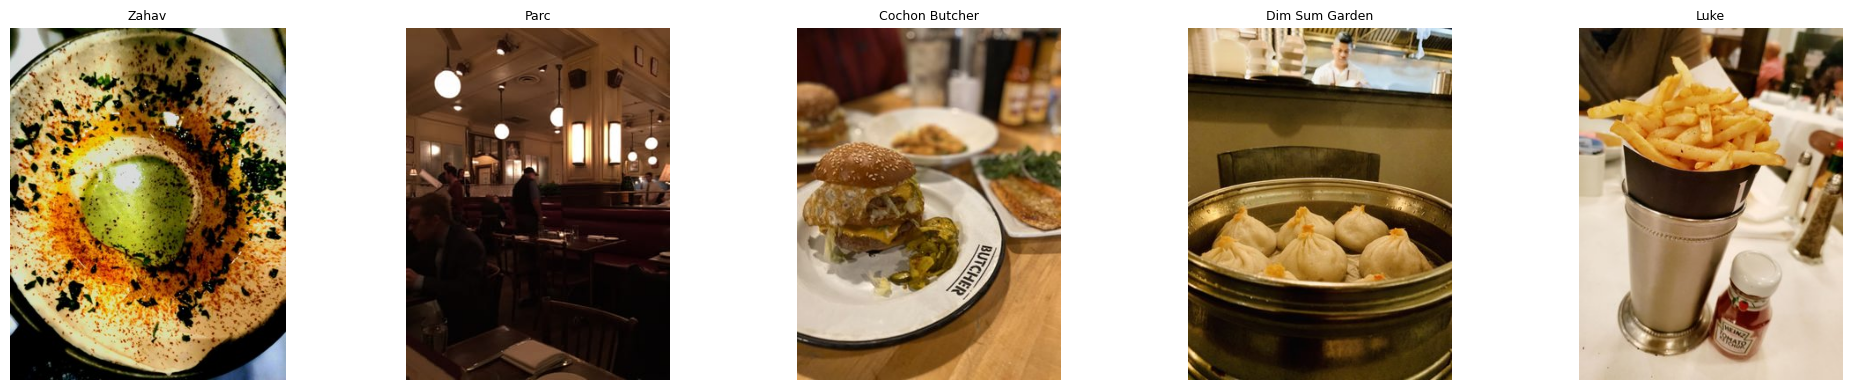


Usuario Qza0EVW1J_k0u8BIqMRbHQ  |  9 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Modo Mio - "I wish I could eat here every night. We tried Modo Mio on a Sunday night for their set priced family style dinner. We made reservations (the place isn't huge so..."
  [5*] Little Nonna's - "SOOOOOOOO good. I usually like pretty classic Italian dishes and Little Nona's has a smaller menu but everything is really a level up.   My one piece of advice ..."
  [4*] Townsend - "We came here for our anniversary dinner and had a lovely table upstairs near the window. They even wrote "Happy Anniversary" on the menu, which was a nice touch..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Commander's Palace (New Orleans) - 4.5* - French, Restaurants, Cocktail Bars, Nightl

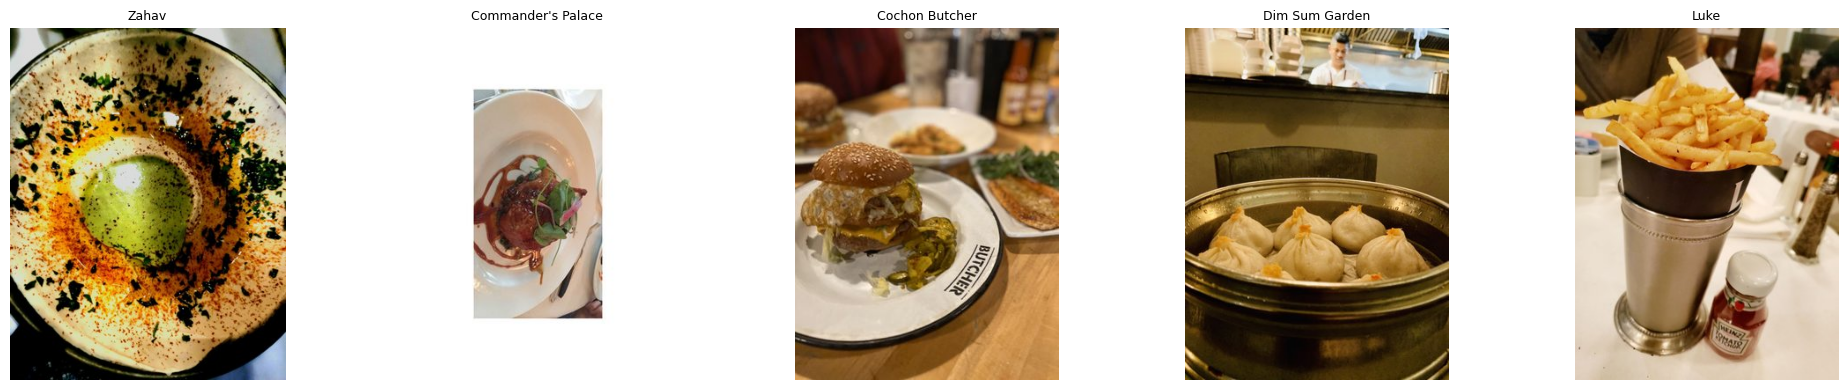


Usuario dt2VNqnnGdnYKor3uHkdlQ  |  8 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Petite Chou Bistro and Champagne Bar - "Love it!  So far our favorite brunch spot in Broad Ripple.  The atmosphere and outdoor seating are great and the ingredients and food are top notch.  I've had t..."
  [5*] Public Greens - "Yum!  Great location just off the Monon with a cute patio and long fire pit for cooler nights.  The menu is constantly changing based on local ingredients (many..."
  [5*] Milktooth - "Loved our first visit. Hour wait around noon on a Saturday in January. We ran a quick errand and then enjoyed some coffees outside while waiting (warm Jan. day ..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Parc (Philadelphia) - 4.0* - Restaurants, French, Wine B

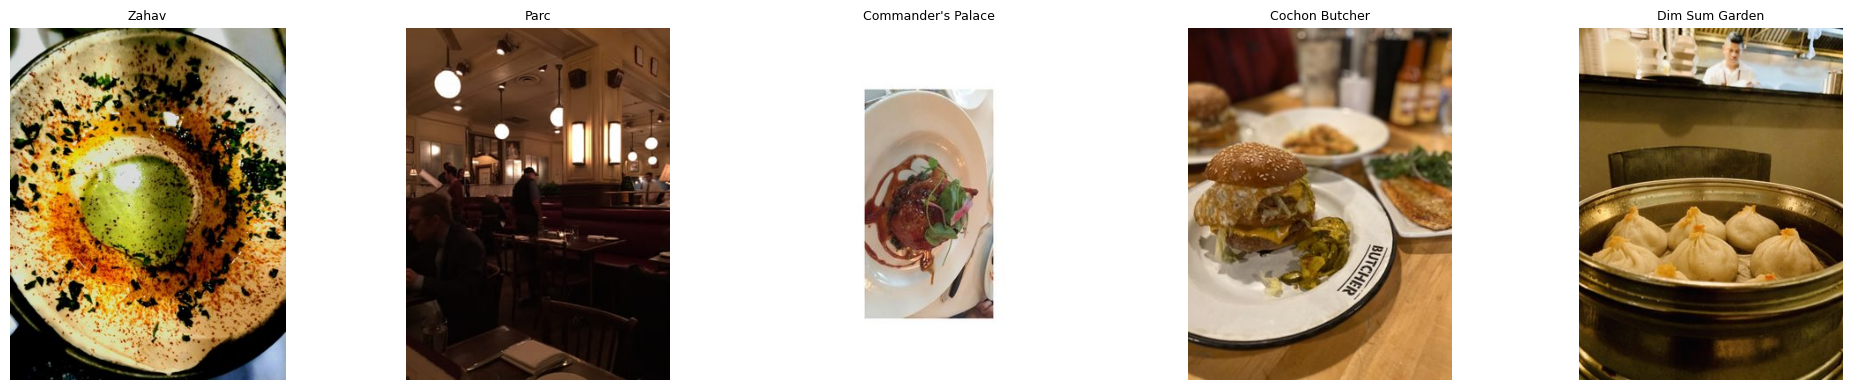


Usuario 4dwFGklOPRts-Tz2CSQZ9A  |  4 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Brocato's Sandwich Shop - "OMG this place is outrageous! If you plan on trying for the first time, plan on coming back in a week to fulfill your new addiction.   Very famous for Deviled C..."
  [5*] West Tampa Sandwich Shop - "Holy Cow! This was my very first time here and I can't believe I've waited this long!!   I had the Cuban with a ropa vieja empanada and both were unbelievably g..."
  [5*] Lee Roy Selmon's Restaurant - "The reliable Lee Roy Selmons, gotta love it! Decisions,decisions, decisions..... this is always the problem when eating here..  I really enjoy this place... I n..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Parc (Philadelphia) - 4.0* - Restaurants

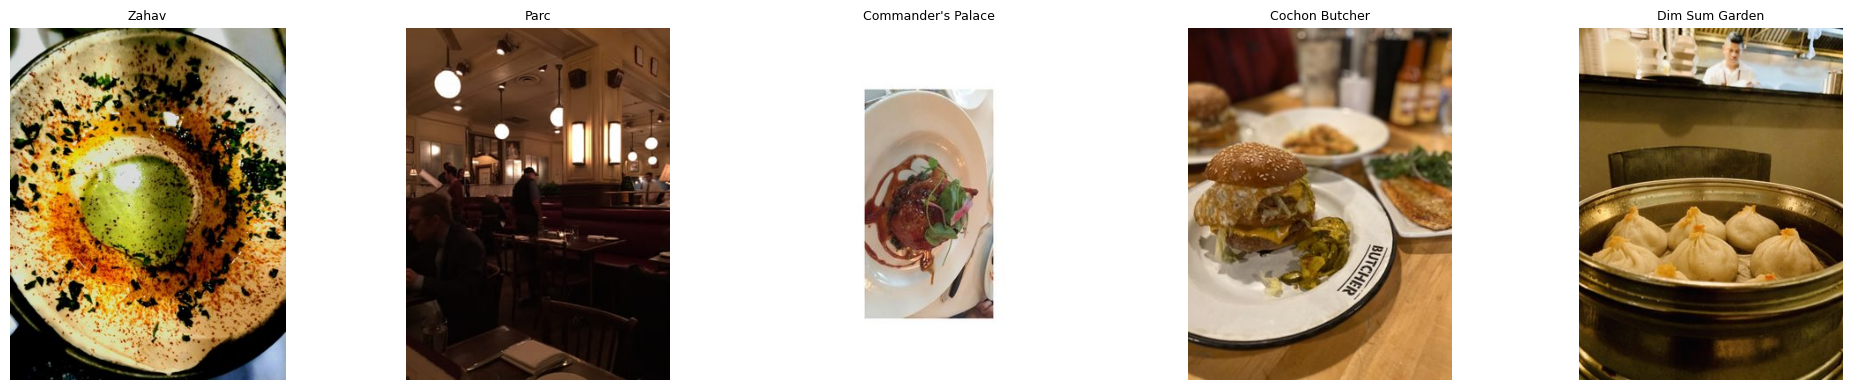


Usuario QdE2T1VEoc-QgNWKTMMixA  |  10 reviews en train
------------------------------------------------------------------------
Historial (top 3 por rating):
  [5*] Napolese Pizzeria - "Delicious pizza and a nice atmosphere. Their Paloma's were amazing and the service was great-- attentive without hovering."
  [5*] HopCat - Broad Ripple - "Two words: crack fries. They can't be beat. Hopcat boasts an impressive beer selection and they rotate regularly so there is always something new to try. It's a..."
  [5*] Quills Coffee - "Was downtown while my car was getting maintenance and needed a place to hang out. Found quills which is tucked back a bit on a side street and loved the cozy at..."
------------------------------------------------------------------------
Top 5 recomendaciones:
  1. Zahav (Philadelphia) - 4.5* - Nightlife, Bars, Food, Ethnic Food, Middle Eastern, Vegetari...
  2. Parc (Philadelphia) - 4.0* - Restaurants, French, Wine Bars, Nightlife, American (New), B...
  3. Comma

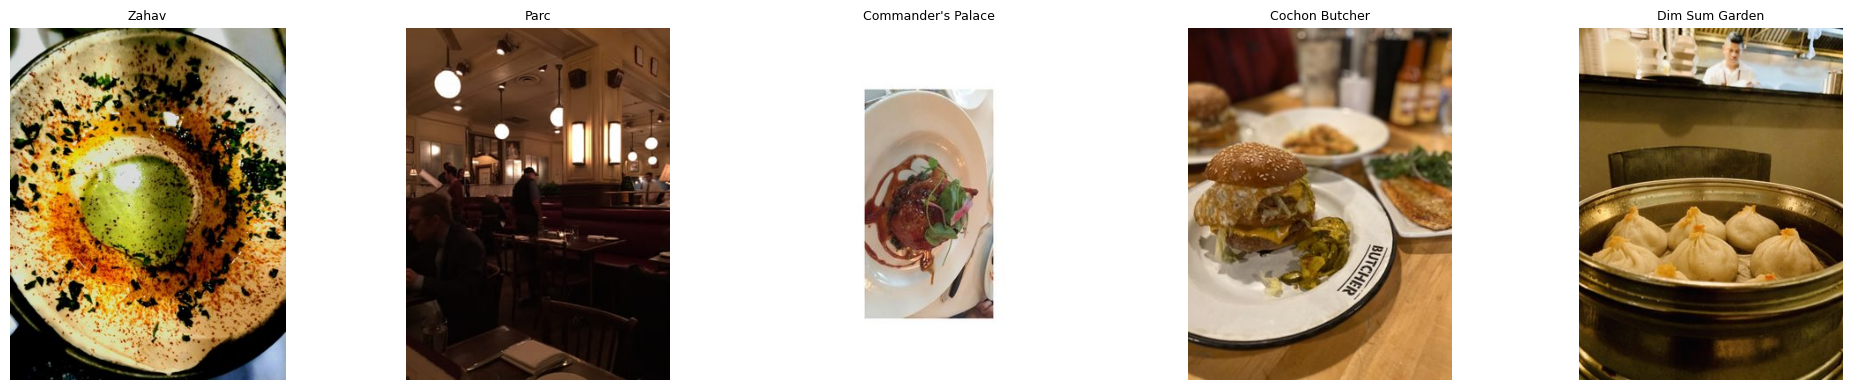

In [12]:
# 5 usuarios fijos por seed (mismos en todos los notebooks)
import pandas as pd
from src.examples import pick_sample_users, show_user_recommendations

restaurants_meta = pd.read_csv('../data/processed/restaurants.csv')
try:
    photos_meta = pd.read_csv('../data/processed/photos.csv')
except FileNotFoundError:
    photos_meta = None

sample_users = pick_sample_users(train_reviews, n=5, seed=42)
print('Usuarios de ejemplo:', sample_users)

for uid in sample_users:
    show_user_recommendations(
        uid,
        lambda u, top_k: model.recommend(u, train_reviews, top_k),
        train_reviews, restaurants_meta, photos=photos_meta,
        top_k=5, show_images=True,
    )